# End-to-End Sales Forecasting & Demand Intelligence System

## Project Objective
This project builds an intelligent retail sales forecasting and demand analysis system.

The system includes:
- Exploratory Data Analysis
- Time Series Feature Engineering
- Weekly and Monthly Sales Aggregation
- Time Series Decomposition
- Stationarity Testing
- SARIMA Forecasting
- Prophet Forecasting
- XGBoost Time Series Forecasting
- Model Comparison
- Category and Region-Level Forecasting
- Anomaly Detection
- Product Demand Segmentation
- Business Recommendations

## Datasets
1. Sales_data.csv — Primary Superstore sales dataset
2. vgsales.csv — Supplementary dataset for multi-source analysis

In [2]:
%pip install pandas numpy matplotlib seaborn plotly statsmodels scikit-learn xgboost prophet joblib -q

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\LENOVO\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
%python --version

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [5]:
%pip install pandas numpy matplotlib seaborn plotly statsmodels scikit-learn xgboost prophet joblib -q

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\LENOVO\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from xgboost import XGBRegressor
from prophet import Prophet

import joblib

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# Task 1 — Data Loading, Merging & Deep Exploration

The primary objective of this section is to:
- Load both datasets
- Inspect their structure
- Clean date and missing-value issues
- Engineer time-based features
- Aggregate sales at weekly and monthly levels
- Answer key business questions

In [8]:
sales = pd.read_csv("Sales_data.csv")
vgsales = pd.read_csv("vgsales.csv")

print("Primary Sales Dataset Shape:", sales.shape)
print("Video Game Sales Dataset Shape:", vgsales.shape)

Primary Sales Dataset Shape: (9800, 18)
Video Game Sales Dataset Shape: (16598, 11)


In [9]:
display(sales.head())
display(vgsales.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [10]:
print("=" * 60)
print("PRIMARY SALES DATASET")
print("=" * 60)

sales.info()

print("\n" + "=" * 60)
print("VIDEO GAME SALES DATASET")
print("=" * 60)

vgsales.info()

PRIMARY SALES DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null  

In [11]:
display(sales.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
sales["Order Date"] = pd.to_datetime(
    sales["Order Date"],
    dayfirst=True,
    errors="coerce"
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"],
    dayfirst=True,
    errors="coerce"
)

print(sales[["Order Date", "Ship Date"]].head())
print("\nDate Range:")
print("Start:", sales["Order Date"].min())
print("End:", sales["Order Date"].max())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18

Date Range:
Start: 2015-01-03 00:00:00
End: 2018-12-30 00:00:00


In [13]:
missing_values = pd.DataFrame({
    "Missing Count": sales.isnull().sum(),
    "Missing Percentage": (
        sales.isnull().mean() * 100
    ).round(2)
})

display(
    missing_values[
        missing_values["Missing Count"] > 0
    ]
)

,Missing Count,Missing Percentage
Postal Code,11,0.11


In [15]:
print("Exact duplicate rows:", sales.duplicated().sum())

print(
    "Duplicate Row IDs:",
    sales["Row ID"].duplicated().sum()
)

print(
    "Duplicate Order IDs:",
    sales["Order ID"].duplicated().sum()
)

Exact duplicate rows: 0
Duplicate Row IDs: 0
Duplicate Order IDs: 4878


Repeated Order ID values are not necessarily errors because one order may contain multiple products.

In [16]:
dtype_table = pd.DataFrame({
    "Column": sales.columns,
    "Data Type": sales.dtypes.astype(str).values,
    "Missing Values": sales.isnull().sum().values,
    "Unique Values": sales.nunique().values
})

display(dtype_table)

,Column,Data Type,Missing Values,Unique Values
0,Row ID,int64,0,9800
1,Order ID,object,0,4922
2,Order Date,datetime64[ns],0,1230
3,Ship Date,datetime64[ns],0,1326
4,Ship Mode,object,0,4
5,Customer ID,object,0,793
6,Customer Name,object,0,793
7,Segment,object,0,3
8,Country,object,0,1
9,City,object,0,529


In [17]:
sales = sales.drop_duplicates().copy()

sales = sales.dropna(
    subset=["Order Date", "Ship Date", "Sales"]
)

sales["Sales"] = pd.to_numeric(
    sales["Sales"],
    errors="coerce"
)

sales = sales.dropna(subset=["Sales"])

print("Cleaned Shape:", sales.shape)

Cleaned Shape: (9800, 18)


In [18]:
sales["Year"] = sales["Order Date"].dt.year
sales["Month"] = sales["Order Date"].dt.month
sales["Month Name"] = sales["Order Date"].dt.month_name()

sales["Week Number"] = (
    sales["Order Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

sales["Day of Week"] = sales["Order Date"].dt.day_name()
sales["Quarter"] = sales["Order Date"].dt.quarter

display(
    sales[
        [
            "Order Date",
            "Year",
            "Month",
            "Month Name",
            "Week Number",
            "Day of Week",
            "Quarter"
        ]
    ].head()
)

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter
0,2017-11-08,2017,11,November,45,Wednesday,4
1,2017-11-08,2017,11,November,45,Wednesday,4
2,2017-06-12,2017,6,June,24,Monday,2
3,2016-10-11,2016,10,October,41,Tuesday,4
4,2016-10-11,2016,10,October,41,Tuesday,4


In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


sales["Season"] = sales["Month"].apply(get_season)

display(
    sales[
        ["Order Date", "Month", "Season"]
    ].head()
)

,Order Date,Month,Season
0,2017-11-08,11,Autumn
1,2017-11-08,11,Autumn
2,2017-06-12,6,Summer
3,2016-10-11,10,Autumn
4,2016-10-11,10,Autumn


In [20]:
sales["Shipping Days"] = (
    sales["Ship Date"] - sales["Order Date"]
).dt.days

display(
    sales[
        ["Order Date", "Ship Date", "Shipping Days"]
    ].head()
)

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


Multi-source analysis with vgsales.csv

In [21]:
vgsales["Year"] = pd.to_numeric(
    vgsales["Year"],
    errors="coerce"
)

vgsales["Global_Sales"] = pd.to_numeric(
    vgsales["Global_Sales"],
    errors="coerce"
)

vgsales_clean = vgsales.dropna(
    subset=["Year", "Global_Sales"]
).copy()

vgsales_clean["Year"] = (
    vgsales_clean["Year"].astype(int)
)

print("Clean Video Game Dataset Shape:", vgsales_clean.shape)

display(vgsales_clean.head())

Clean Video Game Dataset Shape: (16327, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [22]:
superstore_yearly = (
    sales.groupby("Year", as_index=False)["Sales"]
    .sum()
    .rename(columns={"Sales": "Superstore_Sales"})
)

gaming_yearly = (
    vgsales_clean.groupby("Year", as_index=False)["Global_Sales"]
    .sum()
)

multi_source = pd.merge(
    superstore_yearly,
    gaming_yearly,
    on="Year",
    how="left"
)

display(multi_source)

,Year,Superstore_Sales,Global_Sales
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05
3,2018,722052.0192,NaN


In [23]:
multi_source["Superstore_Sales_Index"] = (
    multi_source["Superstore_Sales"]
    / multi_source["Superstore_Sales"].max()
    * 100
)

multi_source["Gaming_Sales_Index"] = (
    multi_source["Global_Sales"]
    / multi_source["Global_Sales"].max()
    * 100
)

display(multi_source)

,Year,Superstore_Sales,Global_Sales,Superstore_Sales_Index,Gaming_Sales_Index
0,2015,479856.2081,264.44,66.457291,100.000000
1,2016,459436.0054,70.93,63.629211,26.822720
2,2017,600192.5500,0.05,83.123173,0.018908
3,2018,722052.0192,NaN,100.000000,NaN


In [ ]:
#Weekly and monthly aggregations can provide insights into sales trends and seasonality. Let's compute the daily sales from the primary sales dataset.
daily_sales = (
    sales
    .set_index("Order Date")
    .resample("D")["Sales"]
    .sum()
    .reset_index()
)

display(daily_sales.head())

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [25]:
weekly_sales = (
    sales
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

display(weekly_sales.head())

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [26]:
monthly_sales = (
    sales
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)

display(monthly_sales.head())

,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


,Total Revenue
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


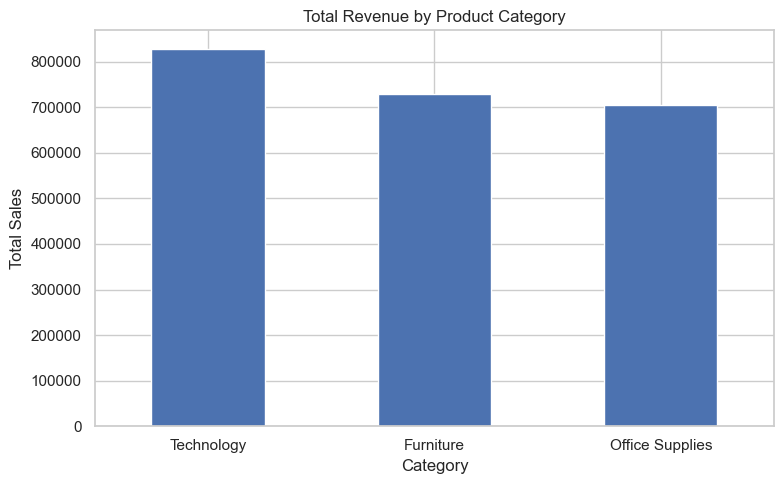

Highest Revenue Category: Technology
Revenue: 827455.87


In [27]:
#Business Question 1 — Highest revenue category
category_revenue = (
    sales.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(category_revenue.to_frame("Total Revenue"))

plt.figure(figsize=(8, 5))
category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(
    "Highest Revenue Category:",
    category_revenue.idxmax()
)

print(
    "Revenue:",
    round(category_revenue.max(), 2)
)

In [28]:
#Business Question 2 — Most consistent regional growth
region_year_sales = (
    sales.groupby(["Year", "Region"])["Sales"]
    .sum()
    .unstack()
)

display(region_year_sales)

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


In [29]:
# Calculate growth consistency
region_growth = region_year_sales.pct_change() * 100

display(region_growth.round(2))

Region,Central,East,South,West
Year,,,,
2015,NaN,NaN,NaN,NaN
2016,-0.48,20.03,-32.21,-8.36
2017,42.22,16.50,33.48,36.47
2018,-2.78,17.71,30.61,35.98


In [30]:
growth_consistency = pd.DataFrame({
    "Average Growth (%)": region_growth.mean(),
    "Growth Volatility (%)": region_growth.std()
})

growth_consistency["Consistency Score"] = (
    growth_consistency["Average Growth (%)"]
    / (
        growth_consistency["Growth Volatility (%)"]
        .abs() + 1e-6
    )
)

growth_consistency = growth_consistency.sort_values(
    "Consistency Score",
    ascending=False
)

display(growth_consistency.round(2))

print(
    "Most Consistent Growth Region:",
    growth_consistency.index[0]
)

,Average Growth (%),Growth Volatility (%),Consistency Score
Region,,,
East,18.08,1.79,10.08
West,21.36,25.74,0.83
Central,12.99,25.35,0.51
South,10.62,37.12,0.29


Most Consistent Growth Region: East


In [31]:
# Business Question 3 — Average shipping time
average_shipping = sales["Shipping Days"].mean()

print(
    f"Overall Average Shipping Time: "
    f"{average_shipping:.2f} days"
)

Overall Average Shipping Time: 3.96 days


In [32]:
shipping_by_region = (
    sales.groupby("Region")["Shipping Days"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)

display(shipping_by_region.round(2))

,mean,median,std,count
Region,,,,
East,3.91,4.0,1.73,2785
West,3.93,4.0,1.81,3140
South,3.96,4.0,1.74,1598
Central,4.07,4.0,1.69,2277


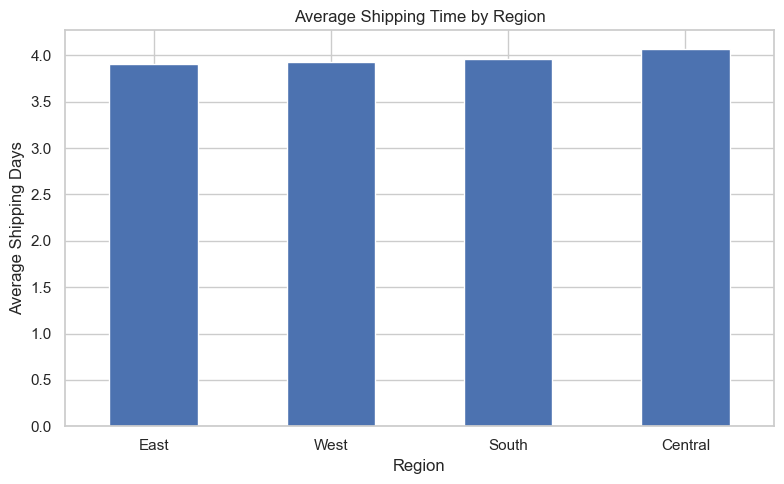

In [33]:
plt.figure(figsize=(8, 5))

shipping_by_region["mean"].plot(
    kind="bar"
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
# Business Question 4 — Seasonal monthly spikes
monthly_by_year = (
    sales.groupby(["Year", "Month"])["Sales"]
    .sum()
    .unstack()
)

display(monthly_by_year.round(2))

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.71,4519.89,55205.80,27906.86,23644.30,34322.94,33781.54,27117.54,81623.53,31453.39,77907.66,68167.06
2016,18066.96,11951.41,32339.32,34154.47,29959.53,23599.37,28608.26,36818.34,63133.61,31011.74,75249.40,74543.60
2017,18542.49,22978.82,51165.06,38679.77,56656.91,39724.49,38320.78,30542.20,69193.39,59583.03,79066.50,95739.12
2018,43476.47,19921.00,58863.41,35541.91,43825.98,48190.73,44825.10,62837.85,86152.89,77448.13,117938.16,83030.39


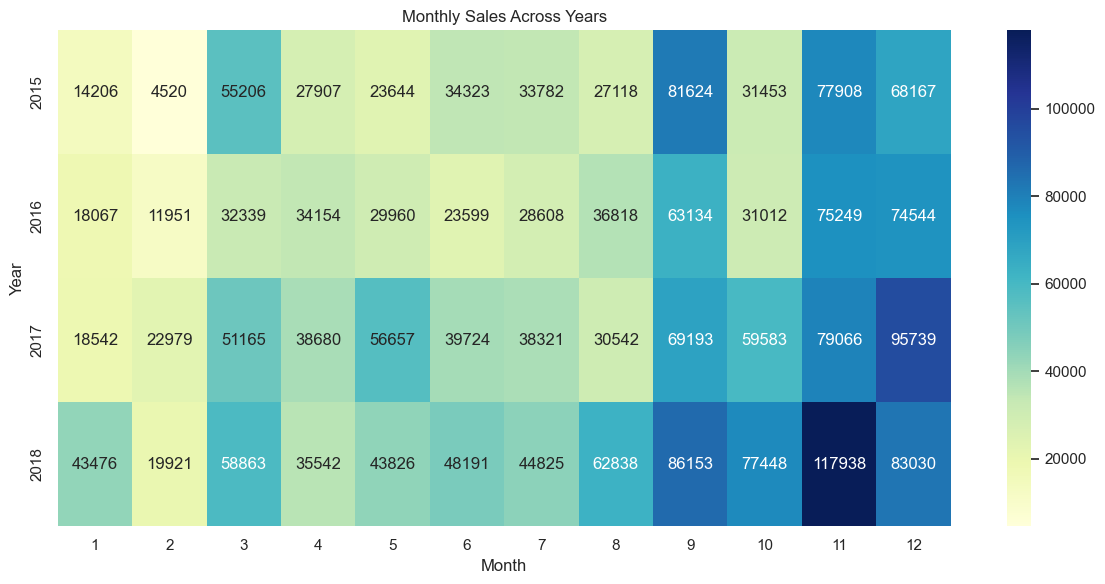

In [35]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    monthly_by_year,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [36]:
# Average sales by month
average_monthly_pattern = (
    sales.groupby("Month")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

display(
    average_monthly_pattern.to_frame(
        "Average Sales"
    )
)

print(
    "Strongest Average Sales Month:",
    average_monthly_pattern.index[0]
)

,Average Sales
Month,
3,290.549393
1,257.627403
10,246.596162
11,241.657496
12,232.619515
8,227.007110
9,221.642106
5,212.533412
6,211.052856


Strongest Average Sales Month: 3


# Task 2 — Time Series Analysis & Decomposition

This section analyzes:
- Long-term trend
- Recurring seasonality
- Unexplained residual variation
- Statistical stationarity

In [37]:
monthly_ts = (
    sales
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
)

monthly_ts = monthly_ts.asfreq("MS", fill_value=0)

display(monthly_ts.head())

Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

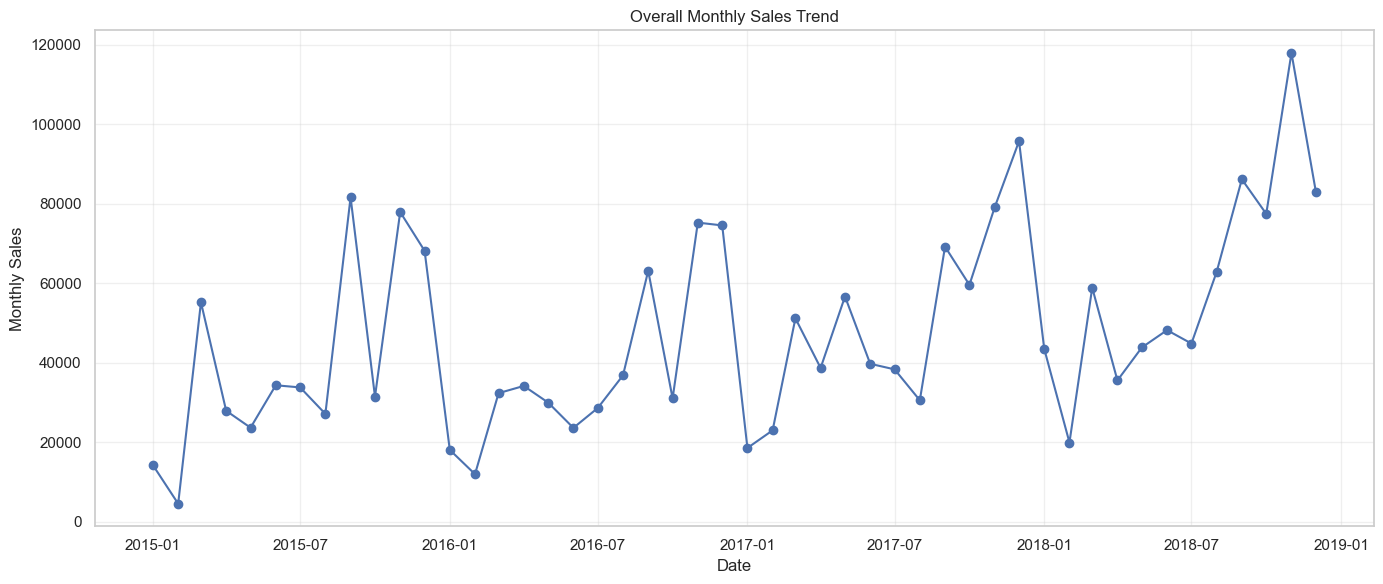

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    marker="o"
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

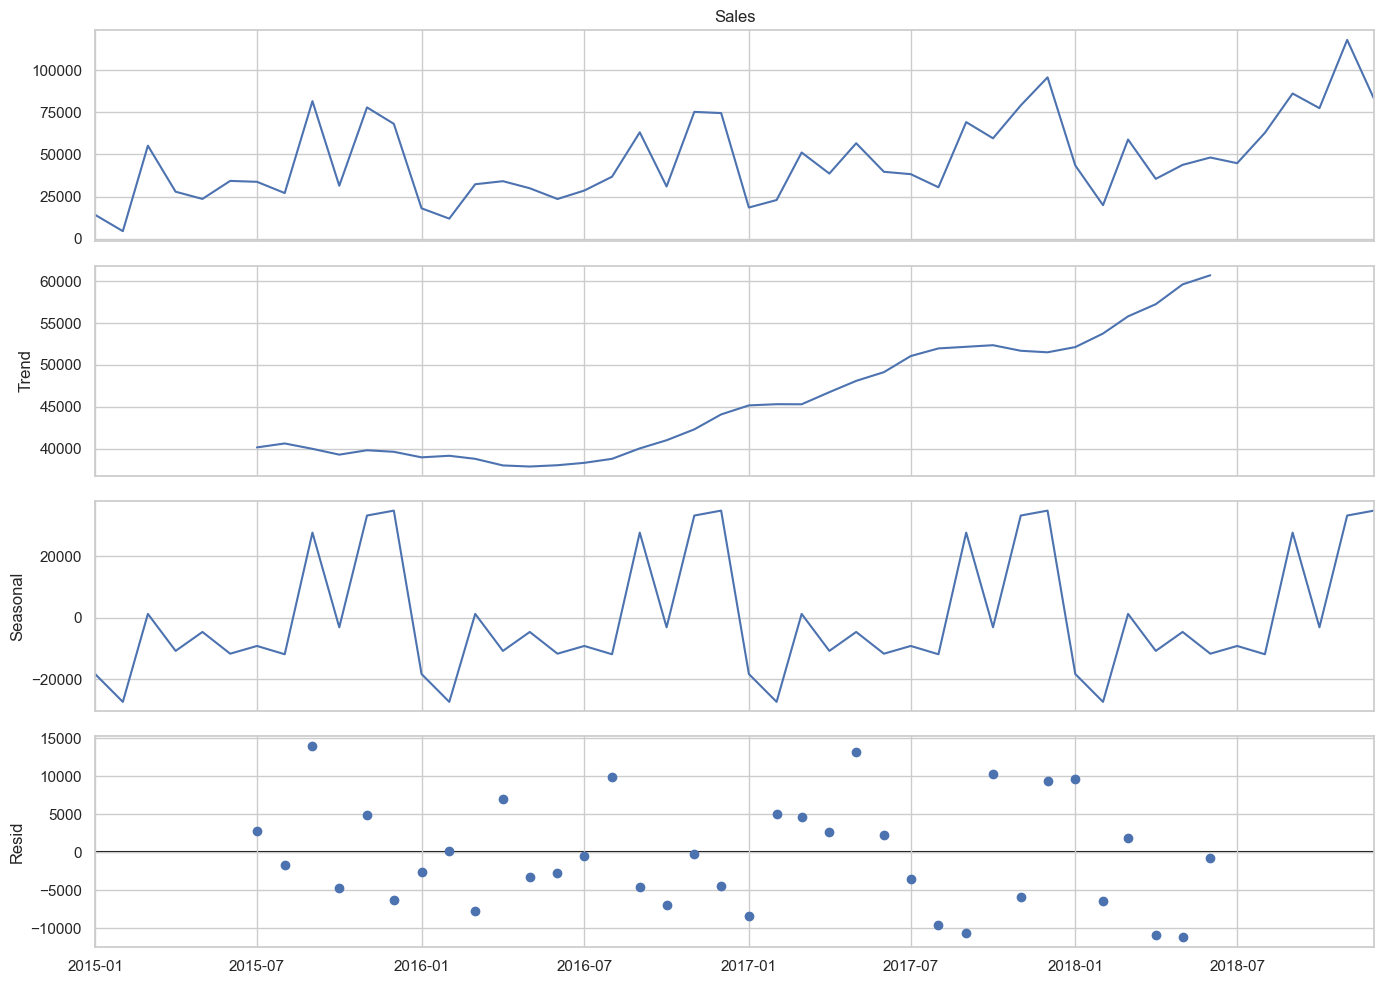

In [39]:
decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

In [40]:
residuals = decomposition.resid.dropna()

highest_noise = (
    residuals.abs()
    .sort_values(ascending=False)
    .head(5)
)

display(
    highest_noise.to_frame(
        "Absolute Residual Noise"
    )
)

,Absolute Residual Noise
Order Date,
2015-09-01,13970.933082
2017-05-01,13193.079793
2018-05-01,11157.549320
2018-04-01,10916.959724
2017-09-01,10642.715643


### Time Series Decomposition Observations

1. The trend component shows how total sales change over the long term, removing short-term monthly fluctuations.
2. The seasonal component identifies recurring patterns that appear approximately every 12 months.
3. Strong positive seasonal values indicate months where demand is consistently above the underlying trend.
4. Large residual values represent unusual periods that cannot be fully explained by trend or seasonality and may correspond to promotions, festive demand, supply disruptions, or exceptional orders.

In [41]:
def adf_test(series, name="Series"):
    result = adfuller(series.dropna())

    print(f"ADF Test for: {name}")
    print("-" * 50)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"P-value       : {result[1]:.4f}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value:.4f}")

    if result[1] < 0.05:
        print("\nConclusion:")
        print("The series is stationary.")
        print(
            "We reject the null hypothesis "
            "of a unit root."
        )
    else:
        print("\nConclusion:")
        print("The series is non-stationary.")
        print(
            "Differencing may be required."
        )

    return result

In [42]:
adf_original = adf_test(
    monthly_ts,
    "Original Monthly Sales"
)

ADF Test for: Original Monthly Sales
--------------------------------------------------
ADF Statistic : -4.4161
P-value       : 0.0003

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008

Conclusion:
The series is stationary.
We reject the null hypothesis of a unit root.


### What does stationarity mean?

A stationary time series has statistical properties such as its mean and variance remaining relatively stable over time.

This is important because many traditional forecasting models assume that the underlying time-series behavior is stable.

For the ADF test:

- **Null hypothesis:** The series is non-stationary.
- **Alternative hypothesis:** The series is stationary.
- If **p-value < 0.05**, we reject the null hypothesis and consider the series stationary.
- If **p-value >= 0.05**, differencing may be required.

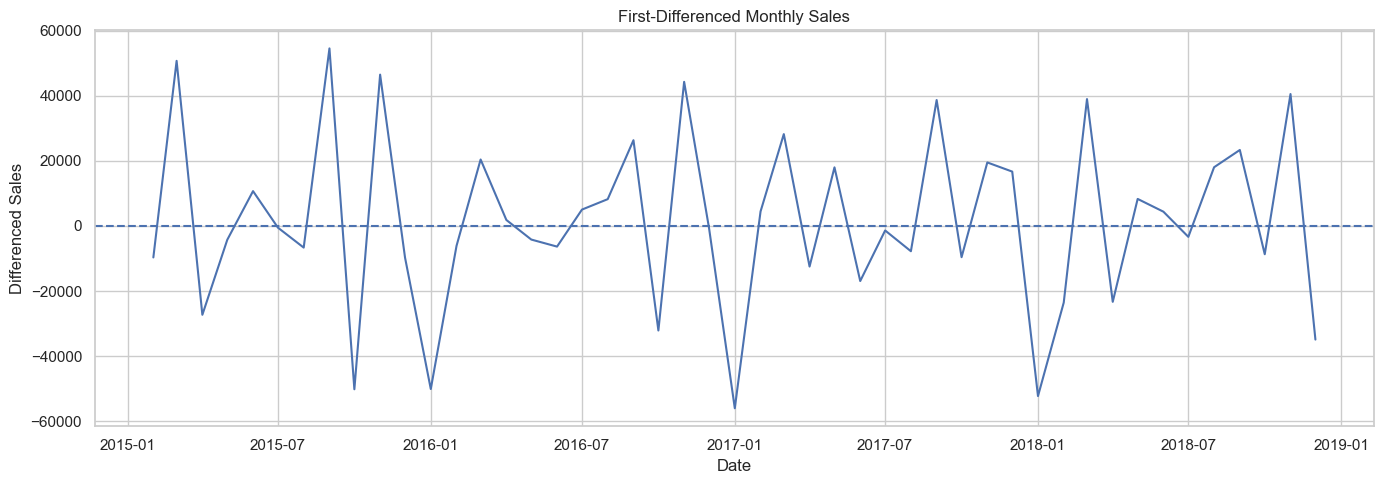

In [43]:
monthly_diff = monthly_ts.diff().dropna()

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_diff.index,
    monthly_diff.values
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("First-Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.tight_layout()
plt.show()

In [45]:
adf_differenced = adf_test(
    monthly_diff,
    "First-Differenced Monthly Sales"
)

ADF Test for: First-Differenced Monthly Sales
--------------------------------------------------
ADF Statistic : -8.7271
P-value       : 0.0000

Critical Values:
1%: -3.6267
5%: -2.9460
10%: -2.6117

Conclusion:
The series is stationary.
We reject the null hypothesis of a unit root.


# Task 3 — Sales Forecasting Using Three Models

Three fundamentally different approaches are compared:

1. SARIMA — Statistical forecasting
2. Prophet — Trend and seasonality-based forecasting
3. XGBoost — Machine-learning forecasting with lag features

For fair comparison, the final 3 observed months are used as a test set.

In [46]:
train_ts = monthly_ts.iloc[:-3]
test_ts = monthly_ts.iloc[-3:]

print("Training Months:", len(train_ts))
print("Testing Months:", len(test_ts))

print("\nTest Period:")
display(test_ts)

Training Months: 45
Testing Months: 3

Test Period:


Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64

In [47]:
def calculate_metrics(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (
                actual[non_zero]
                - predicted[non_zero]
            )
            / actual[non_zero]
        )
    ) * 100

    return mae, rmse, mape

## Model 1 — SARIMA

SARIMA is selected because monthly retail sales often contain:

- Non-seasonal autoregressive behavior
- Differencing requirements
- Moving-average effects
- Annual seasonality

The seasonal period is set to 12 because the data is monthly.

In [48]:
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False
)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    00:17:15   BIC                            403.227
Sample:                                01-01-2015   HQIC                           399.389
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [49]:
sarima_test_result = sarima_fit.get_forecast(
    steps=3
)

sarima_test_pred = (
    sarima_test_result.predicted_mean
)

sarima_test_ci = (
    sarima_test_result.conf_int()
)

display(
    pd.DataFrame({
        "Actual": test_ts.values,
        "SARIMA Prediction": sarima_test_pred.values
    }, index=test_ts.index)
)

,Actual,SARIMA Prediction
Order Date,,
2018-10-01,77448.1312,60331.792073
2018-11-01,117938.1550,91458.220227
2018-12-01,83030.3888,97167.570936


In [50]:
sarima_mae, sarima_rmse, sarima_mape = (
    calculate_metrics(
        test_ts.values,
        sarima_test_pred.values
    )
)

print(f"SARIMA MAE  : {sarima_mae:.2f}")
print(f"SARIMA RMSE : {sarima_rmse:.2f}")
print(f"SARIMA MAPE : {sarima_mape:.2f}%")

SARIMA MAE  : 19244.49
SARIMA RMSE : 19950.07
SARIMA MAPE : 20.53%


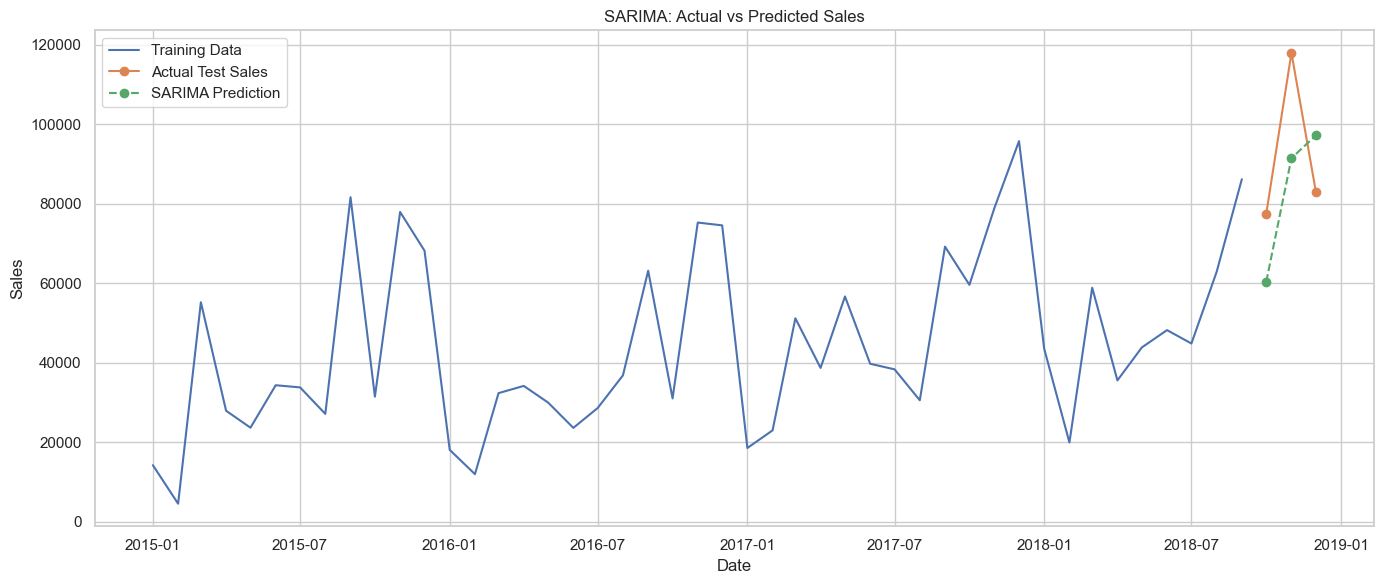

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_ts.index,
    train_ts.values,
    label="Training Data"
)

plt.plot(
    test_ts.index,
    test_ts.values,
    marker="o",
    label="Actual Test Sales"
)

plt.plot(
    test_ts.index,
    sarima_test_pred.values,
    marker="o",
    linestyle="--",
    label="SARIMA Prediction"
)

plt.title("SARIMA: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
final_sarima_model = SARIMAX(
    monthly_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima_model.fit(
    disp=False
)

sarima_future_result = (
    final_sarima_fit.get_forecast(steps=3)
)

sarima_future = (
    sarima_future_result.predicted_mean
)

sarima_future_ci = (
    sarima_future_result.conf_int()
)

display(
    pd.DataFrame({
        "Forecast": sarima_future,
        "Lower CI": sarima_future_ci.iloc[:, 0],
        "Upper CI": sarima_future_ci.iloc[:, 1]
    })
)

,Forecast,Lower CI,Upper CI
2019-01-01,46782.479191,16992.673577,76572.284805
2019-02-01,40285.470518,9596.040110,70974.900926
2019-03-01,72234.203230,41318.855902,103149.550557


In [54]:
# Model 2
prophet_data = monthly_ts.reset_index()

prophet_data.columns = ["ds", "y"]

display(prophet_data.head())

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [55]:
prophet_train = prophet_data.iloc[:-3].copy()
prophet_test = prophet_data.iloc[-3:].copy()

display(prophet_test)

,ds,y
45,2018-10-01,77448.1312
46,2018-11-01,117938.1550
47,2018-12-01,83030.3888


In [56]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

00:20:06 - cmdstanpy - INFO - Chain [1] start processing
00:20:09 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
prophet_test_future = prophet_test[["ds"]].copy()

prophet_test_forecast = prophet_model.predict(
    prophet_test_future
)

display(
    prophet_test_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]
)

,ds,yhat,yhat_lower,yhat_upper
0,2018-10-01,51083.663771,39430.964538,63244.635532
1,2018-11-01,90045.402120,77646.840128,103189.685021
2,2018-12-01,89661.190723,77654.199619,101609.036415


In [58]:
prophet_mae, prophet_rmse, prophet_mape = (
    calculate_metrics(
        prophet_test["y"].values,
        prophet_test_forecast["yhat"].values
    )
)

print(f"Prophet MAE  : {prophet_mae:.2f}")
print(f"Prophet RMSE : {prophet_rmse:.2f}")
print(f"Prophet MAPE : {prophet_mape:.2f}%")

Prophet MAE  : 20296.01
Prophet RMSE : 22487.47
Prophet MAPE : 21.89%


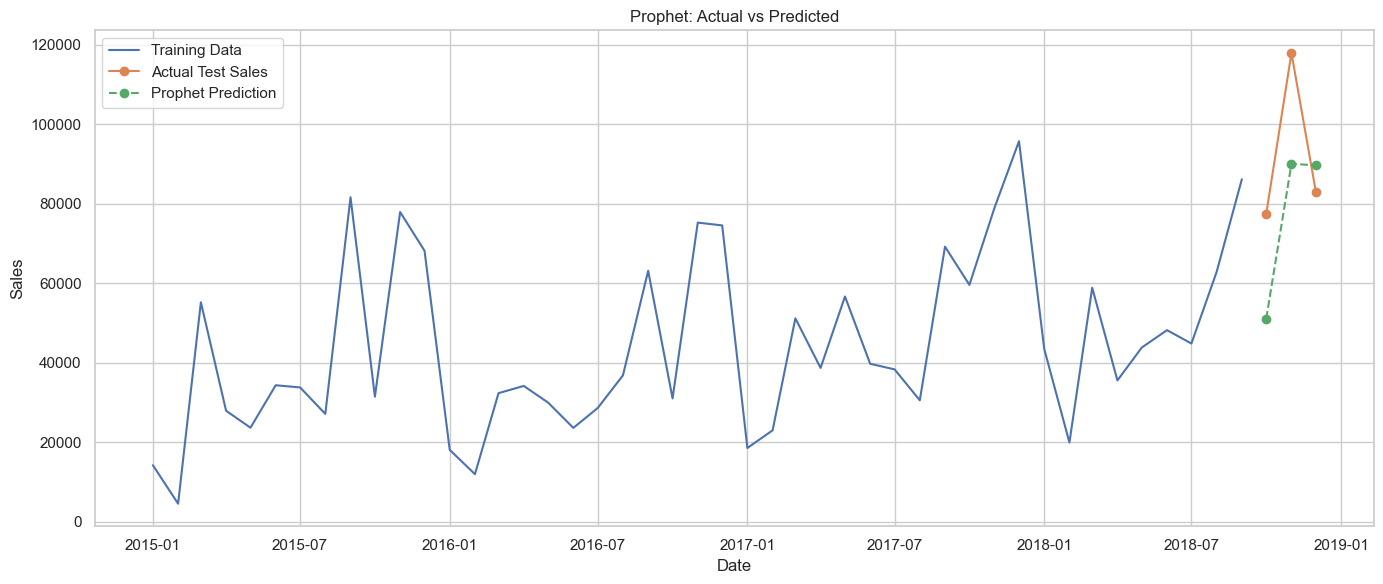

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(
    prophet_train["ds"],
    prophet_train["y"],
    label="Training Data"
)

plt.plot(
    prophet_test["ds"],
    prophet_test["y"],
    marker="o",
    label="Actual Test Sales"
)

plt.plot(
    prophet_test_forecast["ds"],
    prophet_test_forecast["yhat"],
    marker="o",
    linestyle="--",
    label="Prophet Prediction"
)

plt.title("Prophet: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

final_prophet.fit(prophet_data)

future_dates = final_prophet.make_future_dataframe(
    periods=3,
    freq="MS"
)

final_prophet_forecast = final_prophet.predict(
    future_dates
)

prophet_future = (
    final_prophet_forecast.tail(3)
)

display(
    prophet_future[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]
)

00:21:57 - cmdstanpy - INFO - Chain [1] start processing
00:21:59 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-01,42548.142575,28519.588729,58058.092263
49,2019-02-01,33310.125086,19614.792321,47887.978655
50,2019-03-01,80304.673389,65431.962161,93763.136575


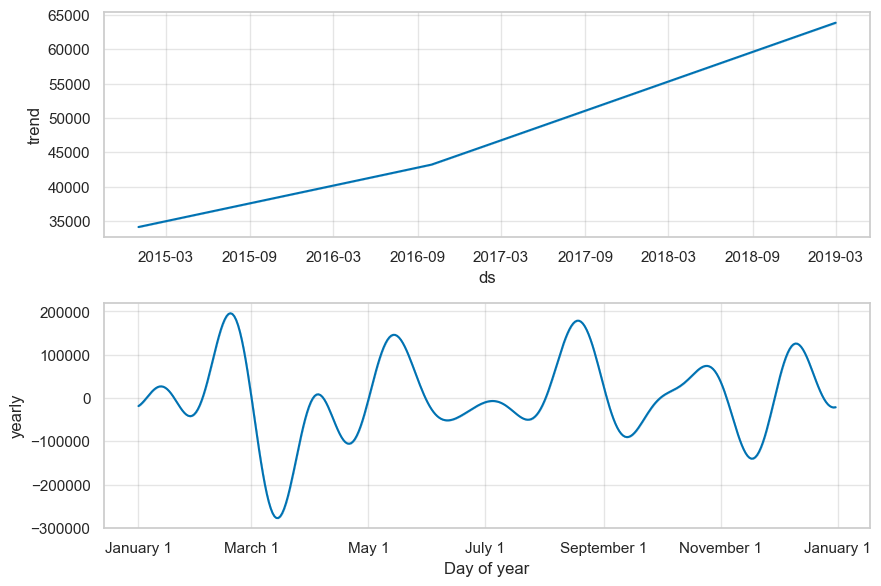

In [62]:
final_prophet.plot_components(
    final_prophet_forecast
)

plt.show()

In [63]:
# Model 3 Xgboost
def create_time_features(series):
    df = series.to_frame(name="Sales").copy()

    df["Lag_1"] = df["Sales"].shift(1)
    df["Lag_2"] = df["Sales"].shift(2)
    df["Lag_3"] = df["Sales"].shift(3)

    df["Rolling_Mean_3"] = (
        df["Sales"]
        .shift(1)
        .rolling(window=3)
        .mean()
    )

    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    df["Season"] = df["Month"].apply(
        get_season
    )

    df = pd.get_dummies(
        df,
        columns=["Season"],
        drop_first=False
    )

    return df.dropna()

In [64]:
xgb_data = create_time_features(
    monthly_ts
)

display(xgb_data.head())

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
Order Date,,,,,,,,,,,
2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,False,True,False,False
2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,False,True,False,False
2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,False,False,True,False
2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,False,False,True,False
2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,False,False,True,False


In [65]:
xgb_train = xgb_data.iloc[:-3].copy()
xgb_test = xgb_data.iloc[-3:].copy()

X_train = xgb_train.drop(
    columns="Sales"
)

y_train = xgb_train["Sales"]

X_test = xgb_test.drop(
    columns="Sales"
)

y_test = xgb_test["Sales"]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (42, 10)
Testing Shape: (3, 10)


In [66]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
xgb_test_pred = xgb_model.predict(
    X_test
)

xgb_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_test_pred
}, index=y_test.index)

display(xgb_results)

,Actual,Predicted
Order Date,,
2018-10-01,77448.1312,71284.093750
2018-11-01,117938.1550,87249.421875
2018-12-01,83030.3888,74860.843750


In [68]:
xgb_mae, xgb_rmse, xgb_mape = (
    calculate_metrics(
        y_test.values,
        xgb_test_pred
    )
)

print(f"XGBoost MAE  : {xgb_mae:.2f}")
print(f"XGBoost RMSE : {xgb_rmse:.2f}")
print(f"XGBoost MAPE : {xgb_mape:.2f}%")

XGBoost MAE  : 15007.44
XGBoost RMSE : 18677.39
XGBoost MAPE : 14.61%


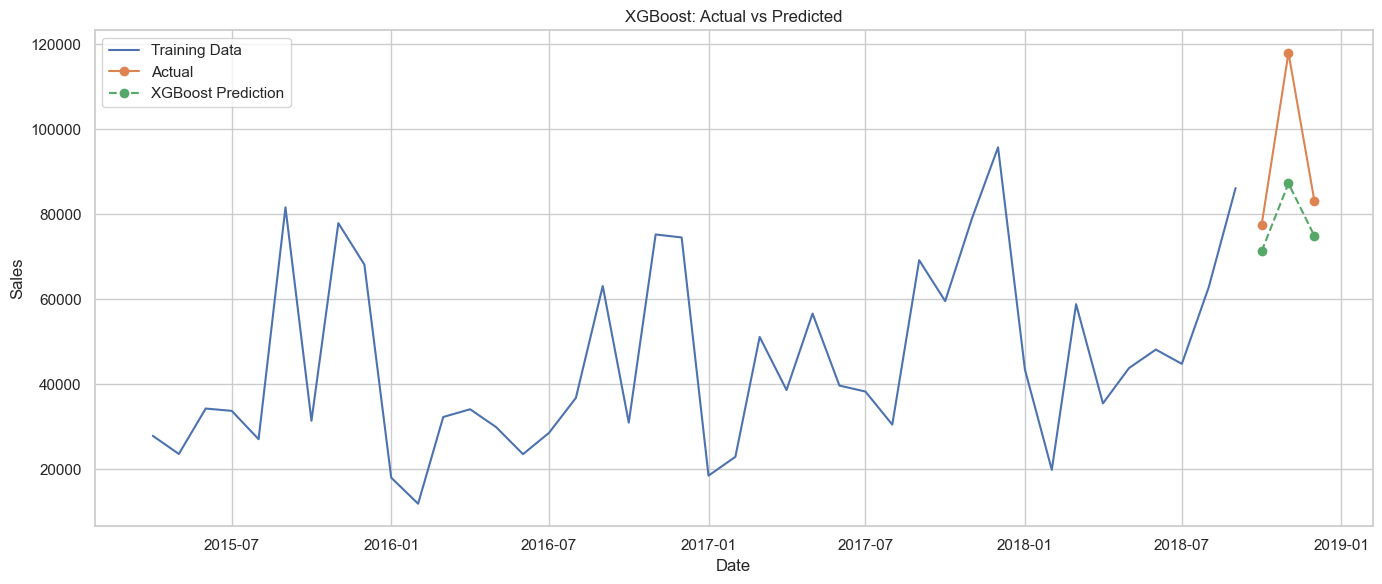

In [69]:
plt.figure(figsize=(14, 6))

plt.plot(
    xgb_train.index,
    xgb_train["Sales"],
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_test_pred,
    marker="o",
    linestyle="--",
    label="XGBoost Prediction"
)

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Recurive Xgboost Forecasting
def recursive_xgb_forecast(
    model,
    history,
    feature_columns,
    steps=3
):
    history = history.copy()
    predictions = []

    for _ in range(steps):

        next_date = (
            history.index[-1]
            + pd.offsets.MonthBegin(1)
        )

        temp_series = pd.concat([
            history,
            pd.Series(
                [np.nan],
                index=[next_date]
            )
        ])

        row = pd.DataFrame(
            index=[next_date]
        )

        row["Lag_1"] = history.iloc[-1]
        row["Lag_2"] = history.iloc[-2]
        row["Lag_3"] = history.iloc[-3]

        row["Rolling_Mean_3"] = (
            history.iloc[-3:].mean()
        )

        row["Month"] = next_date.month
        row["Quarter"] = next_date.quarter

        season = get_season(
            next_date.month
        )

        for col in feature_columns:
            if col.startswith("Season_"):
                row[col] = 0

        season_col = f"Season_{season}"

        if season_col in row.columns:
            row[season_col] = 1

        row = row.reindex(
            columns=feature_columns,
            fill_value=0
        )

        prediction = model.predict(row)[0]

        predictions.append({
            "Date": next_date,
            "Forecast": prediction
        })

        history.loc[next_date] = prediction

    return pd.DataFrame(predictions)

In [72]:
final_xgb_data = create_time_features(
    monthly_ts
)

X_full = final_xgb_data.drop(
    columns="Sales"
)

y_full = final_xgb_data["Sales"]

final_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

final_xgb_model.fit(
    X_full,
    y_full
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [73]:
xgb_future = recursive_xgb_forecast(
    final_xgb_model,
    monthly_ts,
    X_full.columns,
    steps=3
)

display(xgb_future)

,Date,Forecast
0,2019-01-01,44462.664062
1,2019-02-01,37796.785156
2,2019-03-01,50841.308594


In [74]:
comparison_table = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1": [
        sarima_future.iloc[0],
        prophet_future.iloc[0]["yhat"],
        xgb_future.iloc[0]["Forecast"]
    ],

    "Forecast Month 2": [
        sarima_future.iloc[1],
        prophet_future.iloc[1]["yhat"],
        xgb_future.iloc[1]["Forecast"]
    ],

    "Forecast Month 3": [
        sarima_future.iloc[2],
        prophet_future.iloc[2]["yhat"],
        xgb_future.iloc[2]["Forecast"]
    ]
})

comparison_table = comparison_table.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    comparison_table.round(2)
)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,XGBoost,15007.44,18677.39,14.61,44462.66,37796.79,50841.31
1,SARIMA,19244.49,19950.07,20.53,46782.48,40285.47,72234.20
2,Prophet,20296.01,22487.47,21.89,42548.14,33310.13,80304.67


In [75]:
best_model_name = (
    comparison_table.iloc[0]["Model"]
)

print(
    "Recommended Model Based on Lowest RMSE:",
    best_model_name
)

Recommended Model Based on Lowest RMSE: XGBoost


### Production Model Recommendation

The production recommendation is based primarily on out-of-sample forecasting performance rather than personal preference.

The model with the lowest RMSE is preferred because RMSE penalizes large forecasting errors more strongly. MAE and MAPE are also considered to ensure that the selected model performs consistently across different error measures.

Operational considerations such as interpretability, retraining complexity, confidence intervals, and stability should also be considered before deployment.

# Task 4 — Product Category & Region-Level Forecasting

Forecasts are generated separately for:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

The objective is to identify which business segment shows the strongest expected upcoming growth.

In [76]:
def prophet_segment_forecast(
    dataframe,
    filter_column,
    filter_value,
    periods=3
):
    segment = dataframe[
        dataframe[filter_column] == filter_value
    ].copy()

    segment_monthly = (
        segment
        .set_index("Order Date")
        .resample("MS")["Sales"]
        .sum()
        .reset_index()
    )

    segment_monthly.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(segment_monthly)

    future = model.make_future_dataframe(
        periods=periods,
        freq="MS"
    )

    forecast = model.predict(future)

    return (
        segment_monthly,
        forecast.tail(periods),
        model
    )

In [77]:
segments = [
    ("Category", "Furniture"),
    ("Category", "Technology"),
    ("Category", "Office Supplies"),
    ("Region", "West"),
    ("Region", "East")
]

segment_forecasts = {}

for column, value in segments:

    history, forecast, model = (
        prophet_segment_forecast(
            sales,
            column,
            value,
            periods=3
        )
    )

    segment_forecasts[value] = {
        "history": history,
        "forecast": forecast,
        "model": model
    }

print("All segment forecasts generated.")

00:29:55 - cmdstanpy - INFO - Chain [1] start processing
00:29:56 - cmdstanpy - INFO - Chain [1] done processing
00:29:56 - cmdstanpy - INFO - Chain [1] start processing
00:29:57 - cmdstanpy - INFO - Chain [1] done processing
00:29:57 - cmdstanpy - INFO - Chain [1] start processing
00:29:58 - cmdstanpy - INFO - Chain [1] done processing
00:29:59 - cmdstanpy - INFO - Chain [1] start processing
00:30:00 - cmdstanpy - INFO - Chain [1] done processing
00:30:00 - cmdstanpy - INFO - Chain [1] start processing
00:30:01 - cmdstanpy - INFO - Chain [1] done processing


All segment forecasts generated.


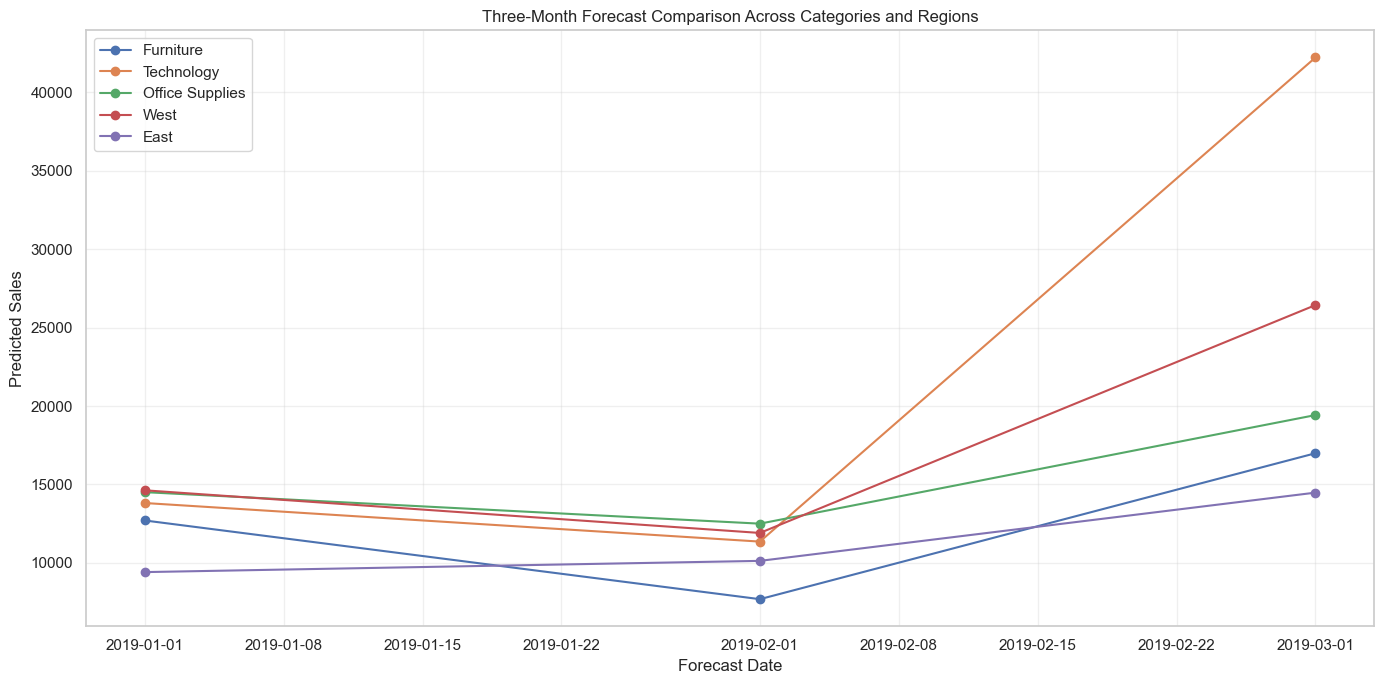

In [78]:
plt.figure(figsize=(14, 7))

for name, result in segment_forecasts.items():

    forecast = result["forecast"]

    plt.plot(
        forecast["ds"],
        forecast["yhat"],
        marker="o",
        label=name
    )

plt.title(
    "Three-Month Forecast Comparison "
    "Across Categories and Regions"
)

plt.xlabel("Forecast Date")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
growth_results = []

for name, result in segment_forecasts.items():

    forecast = result["forecast"]

    first_value = forecast["yhat"].iloc[0]
    last_value = forecast["yhat"].iloc[-1]

    growth_pct = (
        (last_value - first_value)
        / abs(first_value)
    ) * 100

    growth_results.append({
        "Segment": name,
        "Forecast Growth (%)": growth_pct
    })

growth_df = pd.DataFrame(
    growth_results
).sort_values(
    "Forecast Growth (%)",
    ascending=False
)

display(growth_df.round(2))

print(
    "Strongest Upcoming Growth:",
    growth_df.iloc[0]["Segment"]
)

,Segment,Forecast Growth (%)
1,Technology,205.56
3,West,80.72
4,East,53.82
2,Office Supplies,33.86
0,Furniture,33.74


Strongest Upcoming Growth: Technology


# Task 5 — Anomaly Detection in Weekly Sales

Two different methods are used:

1. Isolation Forest
2. Rolling Z-Score Detection

Using two methods helps determine whether unusual weeks are robust anomalies or method-specific detections.

In [80]:
weekly_anomaly = weekly_sales.copy()

weekly_anomaly.columns = [
    "Date",
    "Sales"
]

display(weekly_anomaly.head())

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [81]:
# Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_anomaly["Isolation_Label"] = (
    iso_forest.fit_predict(
        weekly_anomaly[["Sales"]]
    )
)

weekly_anomaly["Isolation_Anomaly"] = (
    weekly_anomaly["Isolation_Label"] == -1
)

print(
    "Isolation Forest Anomalies:",
    weekly_anomaly["Isolation_Anomaly"].sum()
)

Isolation Forest Anomalies: 11


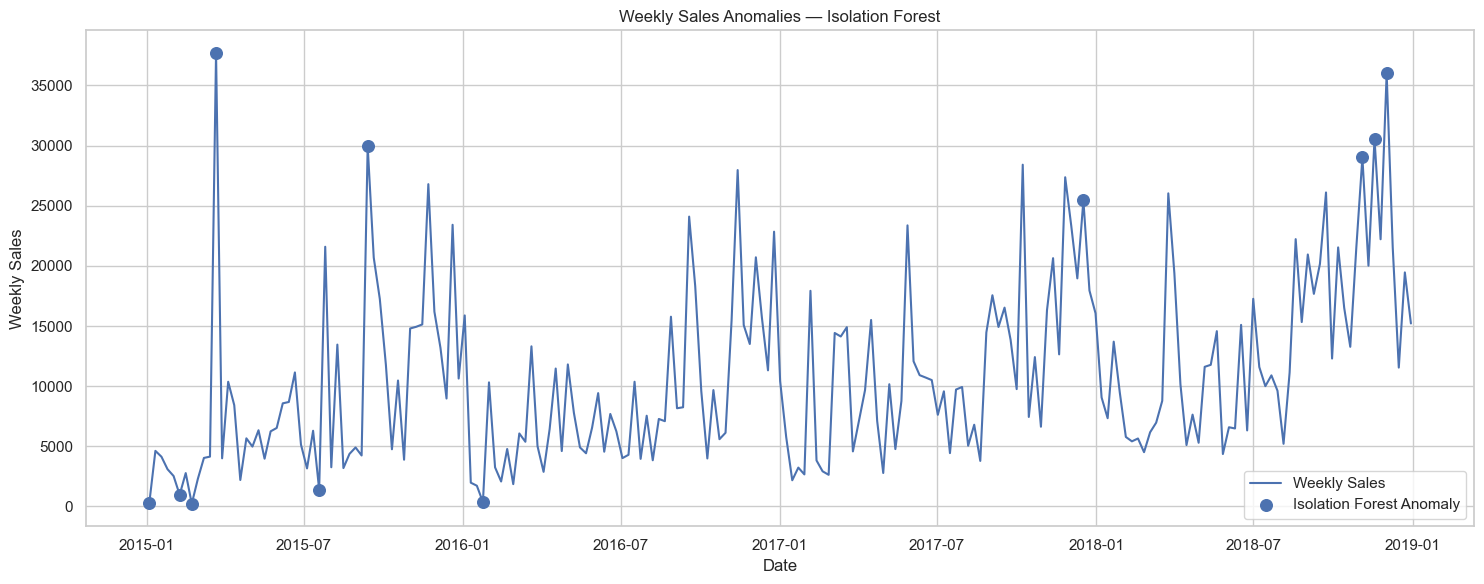

In [82]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_anomaly["Date"],
    weekly_anomaly["Sales"],
    label="Weekly Sales"
)

iso_points = weekly_anomaly[
    weekly_anomaly["Isolation_Anomaly"]
]

plt.scatter(
    iso_points["Date"],
    iso_points["Sales"],
    marker="o",
    s=70,
    label="Isolation Forest Anomaly"
)

plt.title(
    "Weekly Sales Anomalies — Isolation Forest"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# Z Score Method
rolling_window = 8

weekly_anomaly["Rolling_Mean"] = (
    weekly_anomaly["Sales"]
    .rolling(
        window=rolling_window,
        min_periods=4
    )
    .mean()
)

weekly_anomaly["Rolling_Std"] = (
    weekly_anomaly["Sales"]
    .rolling(
        window=rolling_window,
        min_periods=4
    )
    .std()
)

weekly_anomaly["Z_Score"] = (
    (
        weekly_anomaly["Sales"]
        - weekly_anomaly["Rolling_Mean"]
    )
    / weekly_anomaly["Rolling_Std"]
)

weekly_anomaly["Z_Anomaly"] = (
    weekly_anomaly["Z_Score"].abs() > 2
)

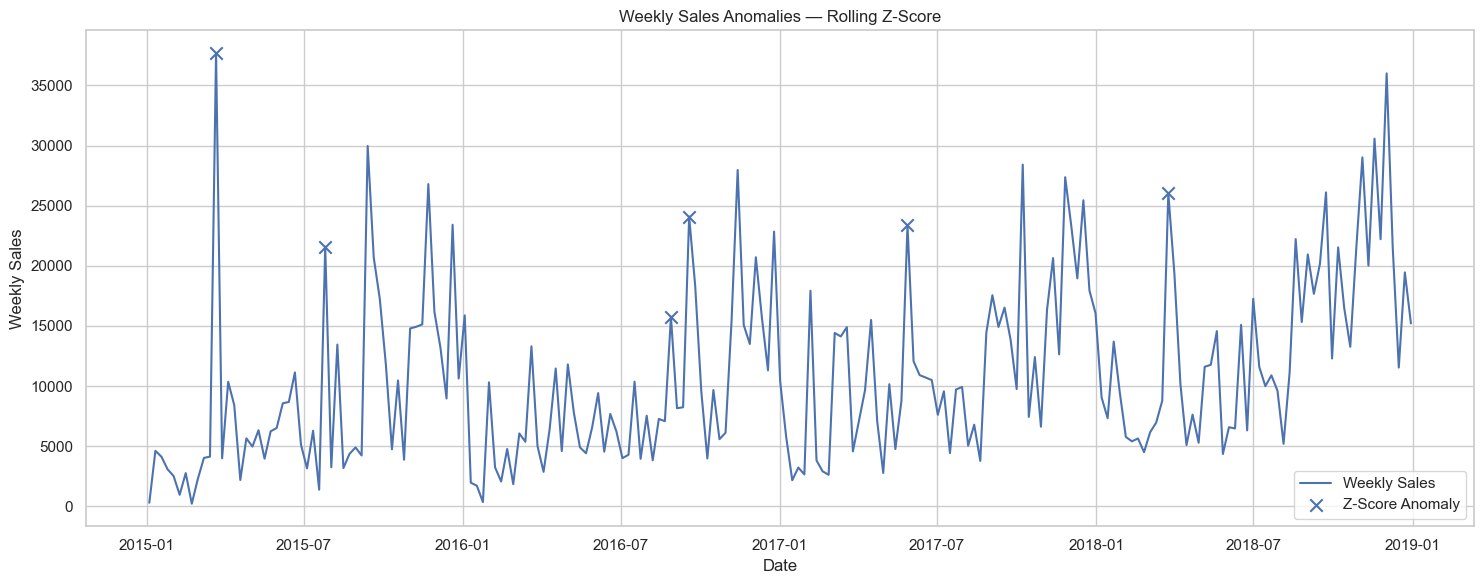

In [84]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_anomaly["Date"],
    weekly_anomaly["Sales"],
    label="Weekly Sales"
)

z_points = weekly_anomaly[
    weekly_anomaly["Z_Anomaly"]
]

plt.scatter(
    z_points["Date"],
    z_points["Sales"],
    marker="x",
    s=80,
    label="Z-Score Anomaly"
)

plt.title(
    "Weekly Sales Anomalies — Rolling Z-Score"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
weekly_anomaly["Both_Methods"] = (
    weekly_anomaly["Isolation_Anomaly"]
    & weekly_anomaly["Z_Anomaly"]
)

comparison = pd.DataFrame({
    "Method": [
        "Isolation Forest",
        "Z-Score",
        "Both Methods"
    ],
    "Anomaly Count": [
        weekly_anomaly["Isolation_Anomaly"].sum(),
        weekly_anomaly["Z_Anomaly"].sum(),
        weekly_anomaly["Both_Methods"].sum()
    ]
})

display(comparison)

,Method,Anomaly Count
0,Isolation Forest,11
1,Z-Score,6
2,Both Methods,1


In [86]:
detected_anomalies = weekly_anomaly[
    weekly_anomaly["Isolation_Anomaly"]
    | weekly_anomaly["Z_Anomaly"]
][
    [
        "Date",
        "Sales",
        "Isolation_Anomaly",
        "Z_Anomaly",
        "Z_Score"
    ]
]

display(
    detected_anomalies.sort_values(
        "Date"
    )
)

,Date,Sales,Isolation_Anomaly,Z_Anomaly,Z_Score
0,2015-01-04,304.508,True,False,NaN
5,2015-02-08,968.534,True,False,-0.959024
7,2015-02-22,224.912,True,False,-1.255254
11,2015-03-22,37703.665,True,True,2.460650
28,2015-07-19,1387.686,True,False,-1.577452
29,2015-07-26,21590.080,False,True,2.136467
36,2015-09-13,29959.137,True,False,1.901161
55,2016-01-24,358.522,True,False,-1.141965
86,2016-08-28,15773.478,False,True,2.053924
89,2016-09-18,24095.960,False,True,2.122082


In [87]:
def anomaly_explanation(row):

    month = row["Date"].month

    if month in [11, 12]:
        return (
            "Possible festive or year-end "
            "promotion demand spike."
        )

    elif month in [1, 2]:
        return (
            "Possible post-holiday demand correction "
            "or seasonal slowdown."
        )

    elif row["Sales"] > weekly_anomaly["Sales"].median():
        return (
            "Possible major bulk order, promotion, "
            "or temporary demand surge."
        )

    else:
        return (
            "Possible stock shortage, demand decline, "
            "or operational disruption."
        )


detected_anomalies = detected_anomalies.copy()

detected_anomalies["Possible Explanation"] = (
    detected_anomalies.apply(
        anomaly_explanation,
        axis=1
    )
)

display(detected_anomalies)

,Date,Sales,Isolation_Anomaly,Z_Anomaly,Z_Score,Possible Explanation
0,2015-01-04,304.508,True,False,NaN,Possible post-holiday demand correction or sea...
5,2015-02-08,968.534,True,False,-0.959024,Possible post-holiday demand correction or sea...
7,2015-02-22,224.912,True,False,-1.255254,Possible post-holiday demand correction or sea...
11,2015-03-22,37703.665,True,True,2.460650,"Possible major bulk order, promotion, or tempo..."
28,2015-07-19,1387.686,True,False,-1.577452,"Possible stock shortage, demand decline, or op..."
29,2015-07-26,21590.080,False,True,2.136467,"Possible major bulk order, promotion, or tempo..."
36,2015-09-13,29959.137,True,False,1.901161,"Possible major bulk order, promotion, or tempo..."
55,2016-01-24,358.522,True,False,-1.141965,Possible post-holiday demand correction or sea...
86,2016-08-28,15773.478,False,True,2.053924,"Possible major bulk order, promotion, or tempo..."
89,2016-09-18,24095.960,False,True,2.122082,"Possible major bulk order, promotion, or tempo..."


# Task 6 — Product Demand Segmentation Using K-Means

Products are segmented at the sub-category level using:

- Total sales volume
- Year-over-year growth rate
- Monthly sales volatility
- Average order value

The purpose is to create actionable stocking strategies for different demand behaviors.

In [88]:
subcat_basic = (
    sales.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Average_Order_Value=("Sales", "mean")
    )
)

In [89]:
subcat_monthly = (
    sales.groupby([
        pd.Grouper(
            key="Order Date",
            freq="MS"
        ),
        "Sub-Category"
    ])["Sales"]
    .sum()
    .reset_index()
)

subcat_volatility = (
    subcat_monthly
    .groupby("Sub-Category")["Sales"]
    .std()
    .rename("Sales_Volatility")
)

In [90]:
subcat_yearly = (
    sales.groupby([
        "Sub-Category",
        "Year"
    ])["Sales"]
    .sum()
    .unstack()
)

first_year = subcat_yearly.columns.min()
last_year = subcat_yearly.columns.max()

subcat_growth = (
    (
        subcat_yearly[last_year]
        - subcat_yearly[first_year]
    )
    / subcat_yearly[first_year].replace(0, np.nan)
) * 100

subcat_growth = subcat_growth.rename(
    "YoY_Growth"
)

In [91]:
cluster_features = (
    subcat_basic
    .join(subcat_volatility)
    .join(subcat_growth)
)

cluster_features = (
    cluster_features
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

display(cluster_features)

,Total_Sales,Average_Order_Value,Sales_Volatility,YoY_Growth
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961
Appliances,104618.4030,227.926804,1821.621539,165.242912
Art,26705.4100,34.019631,330.488343,49.649531
Binders,200028.7850,134.067550,3848.223648,65.778638
Bookcases,113813.1987,503.598224,2220.405080,49.846598
Chairs,322822.7310,531.833165,4407.232960,20.954677
Copiers,146248.0940,2215.880212,5500.774391,479.729510
Envelopes,16128.0460,65.032444,228.218688,-12.121345
Fasteners,3001.9600,14.027850,48.742229,30.468364


In [92]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

scaled_df = pd.DataFrame(
    scaled_features,
    index=cluster_features.index,
    columns=cluster_features.columns
)

display(scaled_df.head())

,Total_Sales,Average_Order_Value,Sales_Volatility,YoY_Growth
Sub-Category,,,,
Accessories,0.315986,-0.363549,0.085085,0.603161
Appliances,-0.288176,-0.345202,-0.347062,0.783458
Art,-1.078397,-0.676171,-1.196761,-0.248947
Binders,0.679509,-0.505405,0.807765,-0.104892
Bookcases,-0.194919,0.125325,-0.119821,-0.247187


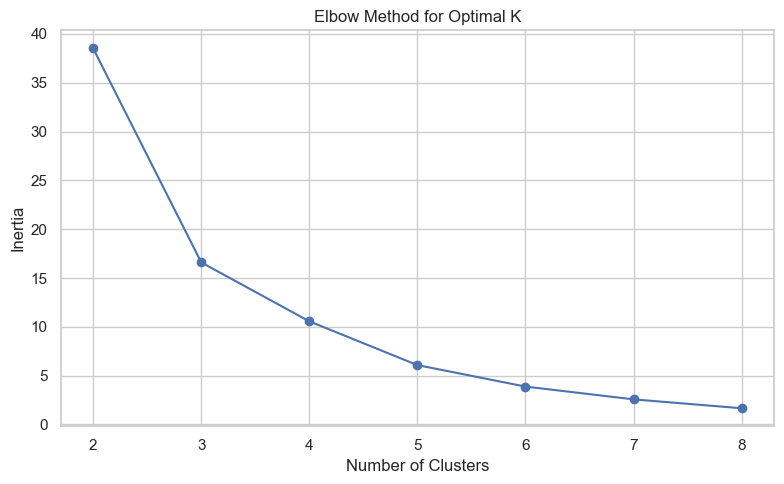

In [93]:
# Elbow Method to determine optimal number of clusters
inertias = []

k_values = range(2, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(scaled_features)

    inertias.append(
        model.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [94]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

cluster_features["Cluster"] = (
    kmeans.fit_predict(
        scaled_features
    )
)

display(cluster_features)

,Total_Sales,Average_Order_Value,Sales_Volatility,YoY_Growth,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,0
Appliances,104618.4030,227.926804,1821.621539,165.242912,2
Art,26705.4100,34.019631,330.488343,49.649531,2
Binders,200028.7850,134.067550,3848.223648,65.778638,0
Bookcases,113813.1987,503.598224,2220.405080,49.846598,2
Chairs,322822.7310,531.833165,4407.232960,20.954677,0
Copiers,146248.0940,2215.880212,5500.774391,479.729510,1
Envelopes,16128.0460,65.032444,228.218688,-12.121345,2
Fasteners,3001.9600,14.027850,48.742229,30.468364,2


In [95]:
cluster_profiles = (
    cluster_features
    .groupby("Cluster")
    .mean()
)

display(
    cluster_profiles.round(2)
)

,Total_Sales,Average_Order_Value,Sales_Volatility,YoY_Growth
Cluster,,,,
0,239495.78,361.13,3489.06,56.47
1,146248.09,2215.88,5500.77,479.73
2,54341.71,142.75,1031.43,58.80
3,189238.63,1645.55,5603.55,-29.79


In [96]:
def assign_cluster_labels(profile_df):

    labels = {}

    sales_median = (
        profile_df["Total_Sales"].median()
    )

    volatility_median = (
        profile_df["Sales_Volatility"].median()
    )

    growth_median = (
        profile_df["YoY_Growth"].median()
    )

    for cluster_id, row in profile_df.iterrows():

        if (
            row["Total_Sales"] >= sales_median
            and row["Sales_Volatility"] < volatility_median
        ):
            label = "High Volume, Stable Demand"

        elif (
            row["Sales_Volatility"] >= volatility_median
            and row["Total_Sales"] < sales_median
        ):
            label = "Low Volume, High Volatility"

        elif row["YoY_Growth"] >= growth_median:
            label = "Growing Demand"

        else:
            label = "Declining / Slow Demand"

        labels[cluster_id] = label

    return labels


cluster_labels = assign_cluster_labels(
    cluster_profiles
)

cluster_features["Demand_Segment"] = (
    cluster_features["Cluster"]
    .map(cluster_labels)
)

display(cluster_features)

,Total_Sales,Average_Order_Value,Sales_Volatility,YoY_Growth,Cluster,Demand_Segment
Sub-Category,,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,0,"High Volume, Stable Demand"
Appliances,104618.4030,227.926804,1821.621539,165.242912,2,Growing Demand
Art,26705.4100,34.019631,330.488343,49.649531,2,Growing Demand
Binders,200028.7850,134.067550,3848.223648,65.778638,0,"High Volume, Stable Demand"
Bookcases,113813.1987,503.598224,2220.405080,49.846598,2,Growing Demand
Chairs,322822.7310,531.833165,4407.232960,20.954677,0,"High Volume, Stable Demand"
Copiers,146248.0940,2215.880212,5500.774391,479.729510,1,"Low Volume, High Volatility"
Envelopes,16128.0460,65.032444,228.218688,-12.121345,2,Growing Demand
Fasteners,3001.9600,14.027850,48.742229,30.468364,2,Growing Demand


In [98]:
# PCA
pca = PCA(
    n_components=2,
    random_state=42
)

pca_components = pca.fit_transform(
    scaled_features
)

pca_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "Cluster": cluster_features["Cluster"].values,
    "Sub-Category": cluster_features.index
})

display(pca_df)

,PC1,PC2,Cluster,Sub-Category
0,0.200367,0.116729,0,Accessories
1,-0.264248,0.707660,2,Appliances
2,-1.676784,0.535820,2,Art
3,0.484161,-0.805597,0,Binders
4,-0.176589,0.003166,2,Bookcases
5,1.479554,-1.711393,0,Chairs
6,4.046026,2.979941,1,Copiers
7,-1.920711,0.234844,2,Envelopes
8,-1.960973,0.583155,2,Fasteners
9,-0.798984,0.421706,2,Furnishings


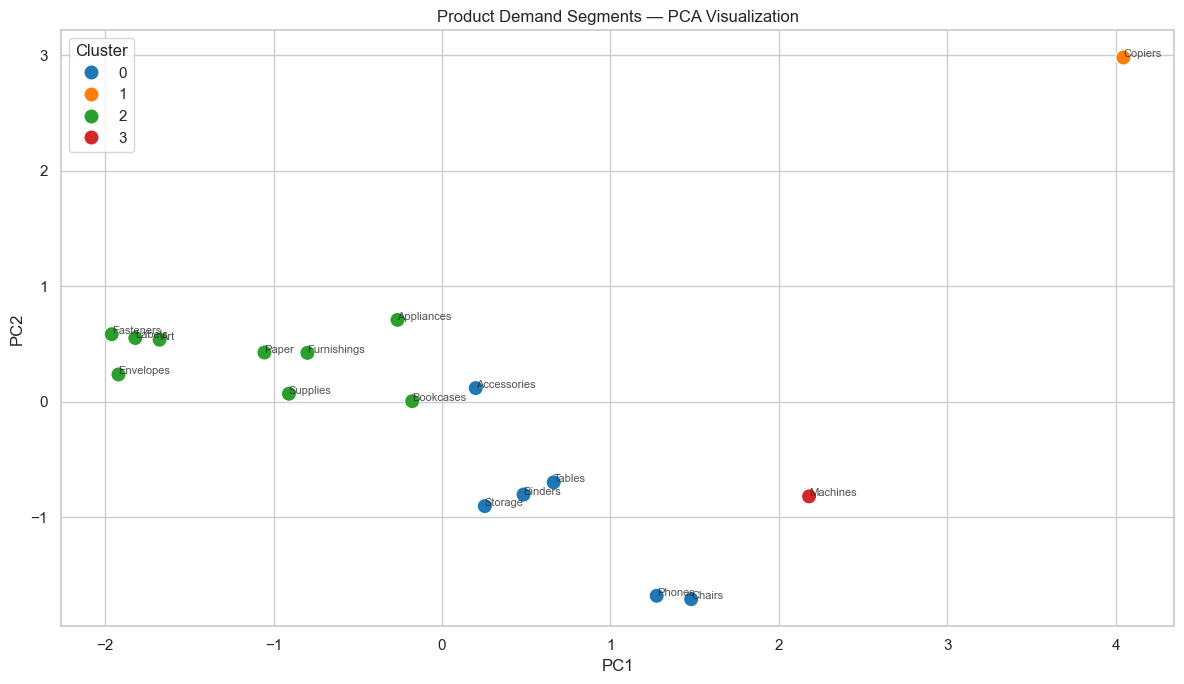

In [99]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=120
)

for _, row in pca_df.iterrows():

    plt.annotate(
        row["Sub-Category"],
        (row["PC1"], row["PC2"]),
        fontsize=8,
        alpha=0.8
    )

plt.title(
    "Product Demand Segments — PCA Visualization"
)

plt.tight_layout()
plt.show()

In [100]:
stocking_strategy = {
    "High Volume, Stable Demand":
        "Maintain high base stock and use frequent replenishment.",

    "Low Volume, High Volatility":
        "Keep conservative safety stock and monitor demand frequently.",

    "Growing Demand":
        "Gradually increase reorder levels and supplier capacity.",

    "Declining / Slow Demand":
        "Reduce inventory exposure and avoid overstocking."
}

strategy_table = (
    cluster_features[
        ["Cluster", "Demand_Segment"]
    ]
    .copy()
)

strategy_table["Stocking Strategy"] = (
    strategy_table["Demand_Segment"]
    .map(stocking_strategy)
)

display(strategy_table)

,Cluster,Demand_Segment,Stocking Strategy
Sub-Category,,,
Accessories,0,"High Volume, Stable Demand",Maintain high base stock and use frequent repl...
Appliances,2,Growing Demand,Gradually increase reorder levels and supplier...
Art,2,Growing Demand,Gradually increase reorder levels and supplier...
Binders,0,"High Volume, Stable Demand",Maintain high base stock and use frequent repl...
Bookcases,2,Growing Demand,Gradually increase reorder levels and supplier...
Chairs,0,"High Volume, Stable Demand",Maintain high base stock and use frequent repl...
Copiers,1,"Low Volume, High Volatility",Keep conservative safety stock and monitor dem...
Envelopes,2,Growing Demand,Gradually increase reorder levels and supplier...
Fasteners,2,Growing Demand,Gradually increase reorder levels and supplier...


# Final Conclusions

This project developed an end-to-end demand intelligence workflow combining statistical forecasting, machine learning, anomaly detection, and product segmentation.

## Key Outcomes

- Historical sales were transformed into daily, weekly, and monthly time series.
- Trend and seasonal behavior were analyzed through decomposition.
- Stationarity was tested statistically using the Augmented Dickey-Fuller test.
- SARIMA, Prophet, and XGBoost were evaluated using the same chronological holdout period.
- The production model recommendation was based on MAE, RMSE, and MAPE rather than subjective preference.
- Weekly anomalies were identified using both Isolation Forest and rolling Z-Score detection.
- Product sub-categories were segmented using K-Means clustering and PCA.
- Each demand segment was translated into an actionable inventory strategy.

## Business Value

The resulting system can help management:

1. Plan inventory using forward-looking sales estimates.
2. Detect unusual demand behavior before it becomes a larger operational problem.
3. Apply differentiated stocking policies across product groups.
4. Reduce the financial risks associated with both overstocking and stockouts.